In [1]:
import os
os.chdir('..')
print(os.getcwd())

d:\pythonProject\IC Lab\Gait_analysis\pyskl


In [16]:
from colab.SSO import SSO
import pandas as pd
def get_best_total_acc_solution(ckpt):
    best_gen = -1
    best_sol = -1
    best_total_acc = -float("inf")
    
    for gen in ckpt:
        for sol in ckpt[gen]:
            message = ckpt[gen][sol].get("message", {})
            try:
                acc_4c = message.get('test_acc_4c', 0)
                if acc_4c > best_total_acc:
                    best_total_acc = acc_4c
                    best_gen = gen
                    best_sol = sol
            except:
                continue

    return best_gen, best_sol, best_total_acc
def before_after(logs):
    before_list = []
    after_list = []
    param_list = []
    for i in logs:
        SSO_reader = SSO()
        SSO_reader.load_result(i)

        # ⬇️ 找出 Total_Acc 最大的 gen, sol
        best_gen, best_sol, best_total_acc = get_best_total_acc_solution(SSO_reader.ckpt)

        before_log = SSO_reader.ckpt[0][0]['message']
        after_log = SSO_reader.ckpt[best_gen][best_sol]['message']

        before = (
            0, 0,
            before_log['train_time'],
            before_log['test_time'],
            before_log['test_acc_4c'],
            before_log['test_acc_3c'],
            before_log['test_acc_2c'],
            before_log['f1'],
            before_log['precision'],
            before_log['recall'],
        )

        after = (
            best_gen,
            best_sol,
            after_log['train_time'],
            after_log['test_time'],
            after_log['test_acc_4c'],
            after_log['test_acc_3c'],
            after_log['test_acc_2c'],
            after_log['f1'],
            after_log['precision'],
            after_log['recall'],
        )

        print(f"🏆 Total_Acc: {best_total_acc:.6f} @ gen={best_gen}, sol={best_sol}")
        print(f"params: {SSO_reader.ckpt[best_gen][best_sol]['x'][0]}")
        param_list.append(SSO_reader.ckpt[best_gen][best_sol]['x'][0])
        before_list.append(before)
        after_list.append(after)

    return before_list, after_list, param_list

In [5]:
SSO_reader = SSO()
SSO_reader.load_result(r"C:\Users\User\Downloads\drunk_4_789_ggen15_gsol2_searchtime60477.525334358215_fec2a3da.pkl")
print(SSO_reader.ckpt[SSO_reader.genBest][SSO_reader.gBest])


🔄 Loading from saved checkpoint...
📂 File ggen: 15, gsol: 2
{'x': ((105.0, 2.0, 3.0, 3.0, 2.0, 72.0, 0.0, 7.0, 3.0, 74.0, 2.0, 0.0, 0.16137740587946345, 0.2429198112315369, 0.06842588063703844, 0.0009967003666952023, 0.5112775417366615, 0.6, 0.7192254335652309), 2.8247767857142856), 'message': {'train_cost': 458.5368, 'train_time': 423.12343096733093, 'test_time': 0.8578555583953857, 'val_acc_4c': 0.8638392857142857, 'val_acc_3c': 0.9654017857142857, 'val_acc_2c': 0.9955357142857143, 'test_acc_4c': 0.7154761904761905, 'test_acc_3c': 0.8148809523809524, 'test_acc_2c': 0.9601190476190476, 'f1': 0.9616485403548941, 'precision': 0.9261300992282249, 'recall': 1.0, 'log': 'results/record_20250409_052205_drunk_j_split4_4C-0.7155_3C-0.8149_2C-0.9601_2CP-0.9261_2CR-1.0000_2CF-0.9616.txt'}, 'p': ((105.0, 2.0, 3.0, 3.0, 2.0, 72.0, 0.0, 7.0, 3.0, 74.0, 2.0, 0.0, 0.16137740587946345, 0.2429198112315369, 0.06842588063703844, 0.0009967003666952023, 0.5112775417366615, 0.6, 0.7192254335652309), 2.824

# 小樣本試驗

In [ ]:
import os
import glob

results_dir = r"D:\pythonProject\IC Lab\Gait_analysis\pyskl\sso_result"
data = 'drunk'
split = 8
# hyp (789, 189, 129, 123)
hyp = 789

# 定義符合條件的檔案名稱模式
pattern = os.path.join(results_dir, f"{data}_{split}_{hyp}_*")

# 搜尋所有符合條件的檔案
logs = glob.glob(pattern)
before_list, after_list, param_list = before_after(logs)

# 找出 test_acc_4c 最大值對應的索引（index=4）
best_index = max(range(len(after_list)), key=lambda i: after_list[i][4])

# 根據這個索引抓出對應的參數
best_param = param_list[best_index]

print("最佳 test_acc_4c：", after_list[best_index][4])
print("最佳參數：", best_param)


🔄 Loading from saved checkpoint...
📂 File ggen: 10, gsol: 1
🏆 Total_Acc: 0.788889 @ gen=4, sol=9
params: (99.0, 2.0, 3.0, 2.0, 0.0, 0.265821853189977, 0.19632040886683266, 0.08373694082425615, 0.0015705782340219366, 0.5858277820140967, 0.5192990196194334, 0.8441669070083623)

🔄 Loading from saved checkpoint...
📂 File ggen: 1, gsol: 2
🏆 Total_Acc: 0.792361 @ gen=6, sol=1
params: (85.0, 2.0, 3.0, 0.0, 0.0, 0.289559029815164, 0.16247521755091776, 0.05588387900348362, 0.0070316126762477, 0.7114006097853004, 0.4916958293944662, 0.8333285332987044)

🔄 Loading from saved checkpoint...
📂 File ggen: 6, gsol: 9
🏆 Total_Acc: 0.792361 @ gen=8, sol=0
params: (106.0, 4.0, 2.0, 1.0, 2.0, 0.2920154139139174, 0.19938399915937707, 0.02803322183654894, 0.009432672000166056, 0.7307672802090608, 0.3809752369212309, 0.13412235683781437)

🔄 Loading from saved checkpoint...
📂 File ggen: 1, gsol: 5
🏆 Total_Acc: 0.803472 @ gen=1, sol=9
params: (128.0, 2.0, 1.0, 3.0, 0.0, 0.24504044898373367, 0.2037733474504907

In [10]:
columns = ["Stage", "genBest", "gBest", "train_time", "test_time", "test_acc_4c", "test_acc_3c", "test_acc_2c", "f1", "precision", "recall"]

df_before = pd.DataFrame(before_list, columns=columns[1:])
df_before.insert(0, "Stage", "Before")

df_after = pd.DataFrame(after_list, columns=columns[1:])
df_after.insert(0, "Stage", "After")

# 合併兩個DataFrame
df_final = pd.concat([df_before, df_after], ignore_index=True)

# 保存為 CSV 檔案
csv_path = "before_after_results.csv"
df_final.to_csv(csv_path, index=False)
print("Done")

Done


# 送入訓練

In [ ]:
from colab.tools import config, prinfo
import torch

params_range = {
    'base_channel'  : (32, 128),
    'num_init'      : (1, 4),
    'stride_init'   : (1, 3),

    'act'           : (0, 3),           # activate function  
    'opt'           : (0, 2),           # optimizer

    'dropout_bk'    : (0.15, 0.3),      # dropout in block
    'dropout_fc'    : (0.15, 0.3),      # dropout in fc

    'lr'            : (0.001, 0.1),     # learning rate
    'weight_decay'  : (0.0, 0.01),      # weight_decay
    'momentum'      : (0.5, 0.99),      # momentum
    'margin'        : (0.25, 1),        # margin in Triplet Loss
    'lambda_val'    : (0.0, 0.9),       # The ratio of Triplet Loss compare to Cross Entropy
}

# 設定初始解
params = {
    'data'          : 'drunk',          # 我自己讀特定資料集的方式
    'batch'         : 128,              # 可以調整~~
    'epoch'         : 80,               # 可以調整~~
    'feature'       : 'j',              # 我自己讀特定資料集的方式
    'split'         : split,

    'base_channel'  : config[split]['base_channel'],           # output_channel in init_layer
    'num_init'      : config[split]['num_init'],
    'stride_init'   : 1, 

    'num_in'        : 0,                # num_layers_input_stream 固定捨棄後面兩個stream
    'num_main'      : 0,                # num_layers_main_stream 固定捨棄後面兩個stream

    'act'           : 0,                # activate function
    'opt'           : 0,                # optimizer
    
    'dropout_bk'    : 0,                # dropout in block
    'dropout_fc'    : 0,                # dropout in fc

    'lr'            : 0.1,              # learning rate
    'weight_decay'  : 0.0005,           # weight_decay
    'momentum'      : 0.9,              # momentum
    'margin'        : config[split]['margin'],              # margin in Triplet Loss
    'lambda_val'    : config[split]['lambda'],              # The ratio of Triplet Loss compare to Cross Entropy
}
                                                                                                        
# 不用動
def get_param(X, keys=params_range.keys(), params=params):
    """
    Update `param` dictionary based on `keys` and corresponding values from `X`.

    Parameters:
        X (numpy.ndarray): Array of parameter values corresponding to the keys.
        keys (list): List of parameter names (keys) used to map values in X.
        params_range (dict): Search range for each parameter, where values can be
                            tuples (for range) or lists (for discrete options).

    Returns:
        dict: Updated `param` dictionary with values from `X`, converting to int if needed.
    """
    # 創建 `param` 的拷貝，避免修改原始字典
    param = params.copy()

    # 根據 keys 中的索引更新 param 中對應的鍵
    for i, key in enumerate(keys):
        # 判斷該參數是否需要轉換為整數
        boundary = params_range[key]
        if (
            isinstance(boundary, tuple) and all(isinstance(b, int) for b in boundary)
        ) or (
            isinstance(boundary, list) and all(isinstance(b, int) for b in boundary)
        ):
            # 如果是整數範圍或整數列表，將值轉換為整數
            param[key] = int(X[i])
        else:
            # 否則保留原類型
            param[key] = X[i]

    return param

def fitness(X):

    # **釋放 GPU 記憶體**
    torch.cuda.empty_cache()
    
    param = get_param(X=X)
    param_args = " ".join([f"--{key} {str(value).strip()}" for key, value in param.items()])
    command = f"python -m colab.training_tools.kaggle_train_drunk_aug_multimetric_weight_small_lambda_gpu {param_args}"
    
    try:
        # 使用 `!{command}` 在 Jupyter Notebook / Colab 內執行
        output = !{command}
        # print(output)
        # 解析輸出
        train_cost, train_time, test_time, val_acc_4c, val_acc_3c, val_acc_2c, \
        test_acc_4c, test_acc_3c, test_acc_2c, f1, pre, rec, log = prinfo(output)

    except Exception as e:
        print(f"❌ 發生錯誤: {e}")
        # 確保所有變數有值，避免 `NoneType` 出錯
        train_cost = train_time = test_time = 0
        val_acc_4c = val_acc_3c = val_acc_2c = 0
        test_acc_4c = test_acc_3c = test_acc_2c = 0
        f1 = pre = rec = 0
        log = ""

    # 確保 `NoneType` 不影響計算
    fitness_value = (val_acc_4c or 0)

    # 確保 `log` 不為 `None`
    log = log if log is not None else ""

    record_message = {
        'train_cost': train_cost,
        'train_time': train_time,
        'test_time': test_time,
        'val_acc_4c': val_acc_4c,
        'val_acc_3c': val_acc_3c,
        'val_acc_2c': val_acc_2c,
        'test_acc_4c': test_acc_4c,
        'test_acc_3c': test_acc_3c,
        'test_acc_2c': test_acc_2c,
        'f1': f1,
        'precision': pre,
        'recall': rec,
        'log': log
    }
    
    return fitness_value, record_message

fitness_value, record_message = fitness(best_param)

# 收斂試驗

In [4]:
import os
import glob

results_dir = r"C:\Users\ADMIN\PycharmProjects\Gait\pyskl\sso_result"
data = 'drunk'
split = 1
# hyp (789, 189, 129, 189)
hyp = 123

# 定義符合條件的檔案名稱模式
pattern = os.path.join(results_dir, f"{data}_{split}_{hyp}_*")

# 搜尋所有符合條件的檔案
logs = glob.glob(pattern)
before_list, after_list = before_after(logs)

In [11]:
from colab.SSO import SSO

SSO_reader = SSO()
SSO_reader.load_result(r"D:\pythonProject\IC Lab\Gait_analysis\pyskl\sso_result\drunk_1_129_ggen4_gsol2_searchtime9785.896945476532_ba63ad82.pkl")


🔄 Loading from saved checkpoint...
📂 File ggen: 4, gsol: 2


In [12]:
print(SSO_reader.ckpt[0][0]['message'])
print(SSO_reader.ckpt[SSO_reader.genBest][SSO_reader.gBest]['message'])
print(SSO_reader.ckpt[SSO_reader.genBest][SSO_reader.gBest]['x'])

{'train_cost': 142.3177, 'train_time': 131.44453692436218, 'test_time': 0.9166688919067383, 'val_acc_4c': 0.7890625, 'val_acc_3c': 0.9006696428571429, 'val_acc_2c': 0.9810267857142857, 'test_acc_4c': 0.7285714285714285, 'test_acc_3c': 0.8202380952380952, 'test_acc_2c': 0.9291666666666667, 'f1': 0.9246358454718175, 'precision': 0.9878213802435724, 'recall': 0.8690476190476191, 'log': 'results/record_20250321_193734_drunk_j_split1_4C-0.7286_3C-0.8202_2C-0.9292_2CP-0.9878_2CR-0.8690_2CF-0.9246.txt'}
{'train_cost': 250.3714, 'train_time': 239.40312957763672, 'test_time': 0.9823720455169678, 'val_acc_4c': 0.8314732142857143, 'val_acc_3c': 0.9419642857142857, 'val_acc_2c': 0.9988839285714286, 'test_acc_4c': 0.7517857142857143, 'test_acc_3c': 0.8535714285714285, 'test_acc_2c': 0.9535714285714286, 'f1': 0.9528985507246376, 'precision': 0.9669117647058824, 'recall': 0.9392857142857143, 'log': 'results/record_20250321_203707_drunk_j_split1_4C-0.7518_3C-0.8536_2C-0.9536_2CP-0.9669_2CR-0.9393_2CF-


🔄 Loading from saved checkpoint...
📂 File ggen: 11, gsol: 15

🔄 Loading from saved checkpoint...
📂 File ggen: 19, gsol: 11

🔄 Loading from saved checkpoint...
📂 File ggen: 10, gsol: 19

🔄 Loading from saved checkpoint...
📂 File ggen: 18, gsol: 14

🔄 Loading from saved checkpoint...
📂 File ggen: 12, gsol: 18
1
2
21    2.696429
22    2.726562
23    2.801339
24    2.801339
25    2.801339
26    2.801339
27    2.801339
28    2.801339
29    2.801339
30    2.801339
31    2.801339
32    2.829241
33    2.829241
34    2.829241
35    2.829241
36    2.829241
37    2.829241
38    2.829241
39    2.829241
40    2.831473
41    2.831473
Name: fitness, dtype: float64
3
4
63    2.722098
64    2.771205
65    2.771205
66    2.771205
67    2.771205
68    2.786830
69    2.786830
70    2.803571
71    2.803571
72    2.803571
73    2.803571
74    2.803571
75    2.803571
76    2.803571
77    2.818080
78    2.818080
79    2.818080
80    2.818080
81    2.827009
82    2.827009
83    2.827009
Name: fitness, dtype: 

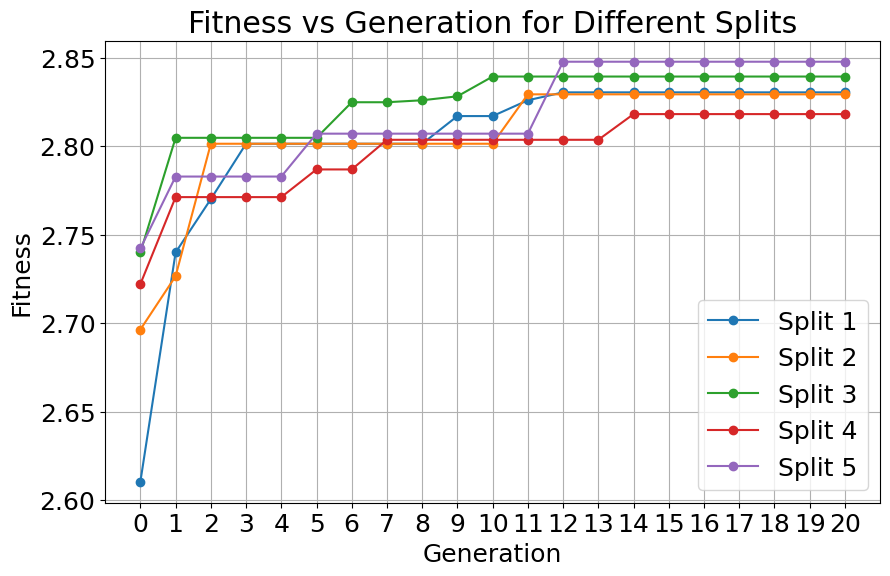

In [36]:
# SSO_reader.plot()
dic = {
    '1' : r"D:\pythonProject\IC Lab\Gait_analysis\pyskl\sso_result\drunk_1_479_收斂試驗_ggen11_gsol15_searchtime69759.33479952812_8cf451c5.pkl",
    '2' : r"D:\pythonProject\IC Lab\Gait_analysis\pyskl\sso_result\drunk_2_479_收斂試驗_ggen19_gsol11_searchtime70035.34123826027_cab74227.pkl",
    '3' : r"D:\pythonProject\IC Lab\Gait_analysis\pyskl\sso_result\drunk_3_479_收斂試驗_ggen10_gsol19_searchtime78091.5849096775_b909ca62.pkl",
    '4' : r"D:\pythonProject\IC Lab\Gait_analysis\pyskl\sso_result\drunk_4_479_收斂試驗_ggen18_gsol14_searchtime61293.00767827034_575d8835.pkl",
    '5' : r"D:\pythonProject\IC Lab\Gait_analysis\pyskl\sso_result\drunk_5_479_收斂試驗_2_ggen12_gsol18_searchtime79429.0804259777_ed83dfaa.pkl",
}
data_list = []
entry = {}
for split in dic.keys():
    SSO_reader = SSO()
    SSO_reader.load_result(dic[split])
    for g in range(len(SSO_reader.ckpt)):
        if g == 0 :
            s = 0
        else:
            s = len(SSO_reader.ckpt[g]) -1
        param_values = SSO_reader.ckpt[g][s]['g'][0]
        fitness = SSO_reader.ckpt[g][s]['g'][1]
        entry = {
            'split': split,
            'generation': g,
            'fitness': fitness
        }
        data_list.append(entry)
df = pd.DataFrame(data_list)
import matplotlib.pyplot as plt
# 繪製圖表
plt.figure(figsize=(10, 6))

# 針對不同的 split 畫線
for split, group in df.groupby('split'):
    print(split)
    if split == '2':
        print(group['fitness'])
        group.loc[group.index[-2:], 'fitness'] = group['fitness'].iloc[-5]
    if split == '4':
        print(group['fitness'])
        group.loc[group.index[-4:], 'fitness'] = group['fitness'].iloc[-5]

    plt.plot(group['generation'], group['fitness'], label=f'Split {split}', marker='o', linestyle='-')


plt.xlabel('Generation')
plt.ylabel('Fitness')
plt.title('Fitness vs Generation for Different Splits')
plt.xticks(df['generation'].astype(int).unique())
plt.legend()
plt.grid(True)
plt.show()
# print(SSO_reader.ckpt[SSO_reader.genBest][SSO_reader.gBest]['message'])
# print(SSO_reader.ckpt[SSO_reader.genBest][SSO_reader.gBest]['x'])


🔄 Loading from saved checkpoint...
📂 File ggen: 11, gsol: 15

🔄 Loading from saved checkpoint...
📂 File ggen: 19, gsol: 11

🔄 Loading from saved checkpoint...
📂 File ggen: 10, gsol: 19

🔄 Loading from saved checkpoint...
📂 File ggen: 18, gsol: 14

🔄 Loading from saved checkpoint...
📂 File ggen: 12, gsol: 18


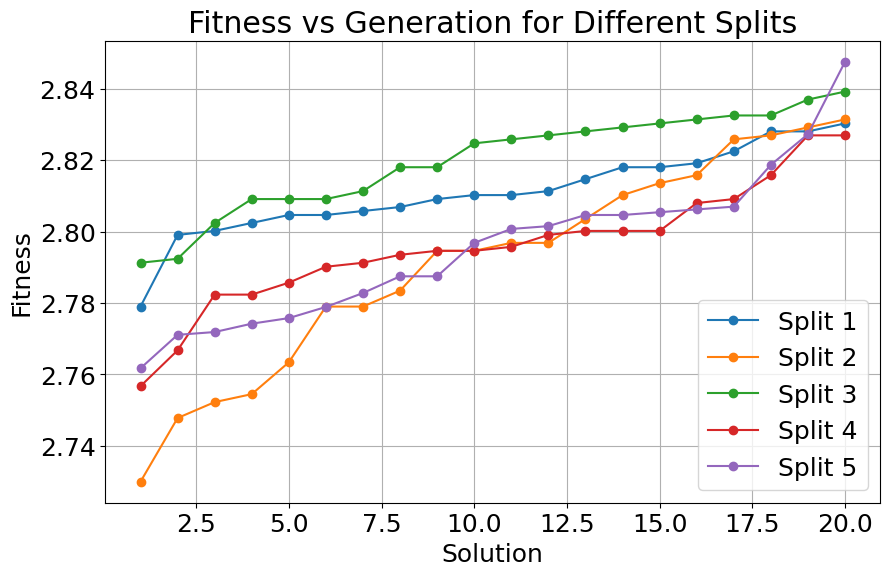

In [53]:
# SSO_reader.plot()
dic = {
    1 : r"D:\pythonProject\IC Lab\Gait_analysis\pyskl\sso_result\drunk_1_479_收斂試驗_ggen11_gsol15_searchtime69759.33479952812_8cf451c5.pkl",
    2 : r"D:\pythonProject\IC Lab\Gait_analysis\pyskl\sso_result\drunk_2_479_收斂試驗_ggen19_gsol11_searchtime70035.34123826027_cab74227.pkl",
    3 : r"D:\pythonProject\IC Lab\Gait_analysis\pyskl\sso_result\drunk_3_479_收斂試驗_ggen10_gsol19_searchtime78091.5849096775_b909ca62.pkl",
    4 : r"D:\pythonProject\IC Lab\Gait_analysis\pyskl\sso_result\drunk_4_479_收斂試驗_ggen18_gsol14_searchtime61293.00767827034_575d8835.pkl",
    5 : r"D:\pythonProject\IC Lab\Gait_analysis\pyskl\sso_result\drunk_5_479_收斂試驗_2_ggen12_gsol18_searchtime79429.0804259777_ed83dfaa.pkl",
}
data_list = []
entry = {}
for split in dic.keys():
    SSO_reader = SSO()
    SSO_reader.load_result(dic[split])
    g = 20
    for s in range(len(SSO_reader.ckpt[20])):
        param_values = SSO_reader.ckpt[g][s]['p'][0]
        fitness = SSO_reader.ckpt[g][s]['p'][1]
        entry = {
            'split': split,
            'sol': s,
            'fitness': fitness
        }
        data_list.append(entry)
df = pd.DataFrame(data_list)
import matplotlib.pyplot as plt
# 繪製圖表
plt.figure(figsize=(10, 6))

# 針對不同的 split 畫線
for split, group in df.groupby('split'):
    group = group.sort_values(by='fitness')
    group['sol'] = range(1, len(group) + 1)
    plt.plot(group['sol'], group['fitness'], label=f'Split {split}', marker='o', linestyle='-')

plt.xlabel('Solution')
plt.ylabel('Fitness')
plt.title('Fitness vs Generation for Different Splits')
plt.legend()
plt.grid(True)
plt.show()
# print(SSO_reader.ckpt[SSO_reader.genBest][SSO_reader.gBest]['message'])
# print(SSO_reader.ckpt[SSO_reader.genBest][SSO_reader.gBest]['x'])

In [ ]:

# param_keys = [
#     'base_channel', 'num_init', 'num_in', 'tkernel_in', 'stride_in', 'oc_in',
#     'num_main', 'tkernel_main', 'stride_main', 'oc_main', 'act', 'opt',
#     'dropout_bk', 'dropout_fc', 'lr', 'weight_decay', 'momentum', 'margin', 'lambda_val'
# ]
# for split in range(1, 6):
#     SSO_reader = SSO()
#     SSO_reader.load_result(dic[split])

#     # 解析數據
#     data_list = []
#     for g in range(len(SSO_reader.ckpt)):
#         for s in range(len(SSO_reader.ckpt[g])):
#             param_values = SSO_reader.ckpt[g][s]['x'][0]
#             fitness = SSO_reader.ckpt[g][s]['x'][1]
#             entry = {param_keys[i]: param_values[i] for i in range(len(param_keys))}
#             entry['fitness'] = fitness
#             data_list.append(entry)

#     # 轉換為 DataFrame
#     df = pd.DataFrame(data_list)

#     import matplotlib.pyplot as plt
#     # 繪製散佈圖
#     for column in df.columns:
#         if column != 'fitness':  # 排除 fitness
#             if column == 'lr':
#                 df = df[df['fitness'] > 2.5]

#                 threshold = df['fitness'].quantile(0.8)
#                 top_20_df = df[df['fitness'] >= threshold]
#                 lr_max = top_20_df['lr'].max()
#                 lr_min = top_20_df['lr'].min()
#                 print(f"SPlit{split} : LR 最大值: {lr_max}, LR 最小值: {lr_min}")

#                 # print(f" LR: {df[column]} | fitness: {df['fitness']}")
#                 plt.figure(figsize=(6, 4))
#                 plt.scatter(df[column], df['fitness'], alpha=0.7)
#                 plt.xlabel(column)
#                 plt.ylabel("Fitness Score")
#                 plt.title(f"Scatter Plot: {column} vs Fitness")
#                 plt.grid(True)
#                 plt.show()

In [8]:
# SSO_reader.plot()
dic = {
    '1' : r"D:\pythonProject\IC Lab\Gait_analysis\pyskl\sso_result\drunk_1_479_收斂試驗_ggen11_gsol15_searchtime69759.33479952812_8cf451c5.pkl",
    '2' : r"D:\pythonProject\IC Lab\Gait_analysis\pyskl\sso_result\drunk_2_479_收斂試驗_ggen19_gsol11_searchtime70035.34123826027_cab74227.pkl",
    '3' : r"D:\pythonProject\IC Lab\Gait_analysis\pyskl\sso_result\drunk_3_479_收斂試驗_ggen10_gsol19_searchtime78091.5849096775_b909ca62.pkl",
    '4' : r"D:\pythonProject\IC Lab\Gait_analysis\pyskl\sso_result\drunk_4_479_收斂試驗_ggen18_gsol14_searchtime61293.00767827034_575d8835.pkl",
    '5' : r"D:\pythonProject\IC Lab\Gait_analysis\pyskl\sso_result\drunk_5_479_收斂試驗_2_ggen12_gsol18_searchtime79429.0804259777_ed83dfaa.pkl",
}
data_list = []
entry = {}
for split in dic.keys():
    SSO_reader = SSO()
    SSO_reader.load_result(dic[split])
    message = SSO_reader.ckpt[SSO_reader.genBest][SSO_reader.gBest]['message']
    entry = {
        'split': split,
        'message': message
    }
    data_list.append(entry)
df = pd.DataFrame(data_list)
for s in df['message']:
    print(s)


🔄 Loading from saved checkpoint...
📂 File ggen: 11, gsol: 15

🔄 Loading from saved checkpoint...
📂 File ggen: 19, gsol: 11

🔄 Loading from saved checkpoint...
📂 File ggen: 10, gsol: 19

🔄 Loading from saved checkpoint...
📂 File ggen: 18, gsol: 14

🔄 Loading from saved checkpoint...
📂 File ggen: 12, gsol: 18
{'train_cost': 257.2094, 'train_time': 246.65261268615723, 'test_time': 0.5101666450500488, 'val_acc_4c': 0.8727678571428571, 'val_acc_3c': 0.9564732142857143, 'val_acc_2c': 0.9966517857142857, 'test_acc_4c': 0.7476190476190476, 'test_acc_3c': 0.8470238095238095, 'test_acc_2c': 0.9654761904761905, 'f1': 0.9645476772616138, 'precision': 0.9912060301507538, 'recall': 0.9392857142857143, 'log': 'results/record_20250323_060431_drunk_j_split1_4C-0.7476_3C-0.8470_2C-0.9655_2CP-0.9912_2CR-0.9393_2CF-0.9645.txt'}
{'train_cost': 395.9186, 'train_time': 384.1302328109741, 'test_time': 0.891798734664917, 'val_acc_4c': 0.8738839285714286, 'val_acc_3c': 0.9575892857142857, 'val_acc_2c': 1.0, 't

In [ ]:
import seaborn as sns
data_list = []
for split in dic.keys():
    SSO_reader = SSO()
    SSO_reader.load_result(dic[split])
    
    for g in range(len(SSO_reader.ckpt)):
        for s in range(len(SSO_reader.ckpt[0])):
            # 檢查是否有 message 欄位
            if 'message' not in SSO_reader.ckpt[g][s]:
                print(f"Warning: No 'message' key found in Split {split}, Generation {g}, Solution {s}")
                continue  # 跳過沒有 message 的數據

            # 檢查 message 欄位內是否有對應的 test_acc 數據
            message = SSO_reader.ckpt[g][s]['message']
            if not all(key in message for key in ['test_acc_4c', 'test_acc_3c', 'test_acc_2c']):
                print(f"Warning: Missing accuracy values in Split {split}, Generation {g}, Solution {s}")
                continue  # 跳過不完整的數據
            
            c4 = message['test_acc_4c']
            c3 = message['test_acc_3c']
            c2 = message['test_acc_2c']

            entry = {
                'split': split,
                'generation': g,
                'test_acc_4c': c4,
                'test_acc_3c': c3,
                'test_acc_2c': c2,
            }
            print(f"Adding entry: {entry}")  # Debug: 確保數據真的加入 data_list
            data_list.append(entry)

# 檢查 data_list 是否有數據
if len(data_list) == 0:
    print("Error: data_list 仍然為空，請檢查 SSO_reader.load_result() 是否正確讀取數據")
else:
    print(f"data_list 共有 {len(data_list)} 筆數據")

# 轉換 data_list 為 DataFrame
df = pd.DataFrame(data_list)

# 確保 DataFrame 不是空的
if df.empty:
    print("DataFrame 仍然為空，無法進行分析")
else:
    unique_splits = df['split'].unique()

    for split in unique_splits:
        df_split = df[df['split'] == split]

        # 繪製相關係數矩陣熱力圖
        correlation_matrix = df_split[['test_acc_4c', 'test_acc_3c', 'test_acc_2c']].corr()

        plt.figure(figsize=(8, 6))
        sns.heatmap(correlation_matrix, annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5)
        plt.title(f"Correlation Matrix for Split {split}")
        plt.show()

        # 繪製 pairplot 來顯示變數之間的散佈圖
        sns.pairplot(df_split, vars=['test_acc_4c', 'test_acc_3c', 'test_acc_2c'], diag_kind='kde')
        plt.suptitle(f"Pairplot for Split {split}", y=1.02)
        plt.show()
